# Project 9: Autoencoder & Variational Autoencoder (VAE)

Moving from discriminative models (classify/predict) to generative models (create new data). Building both a standard Autoencoder and a VAE on MNIST.

**Concepts Covered:**
- Encoder-decoder architecture
- Latent space representation
- Reconstruction loss
- Variational Autoencoder (VAE)
- KL divergence loss
- Reparameterization trick
- Generating new images by sampling latent space
- Latent space visualization

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
Using device: cuda
GPU: Tesla T4


---
## Understanding Autoencoders

```
Standard Autoencoder:
  Input (784) -> Encoder -> Latent (32) -> Decoder -> Output (784)
  Goal: output = input (learn to reconstruct)

VAE:
  Input (784) -> Encoder -> mean, std -> Sample -> Decoder -> Output (784)
  Goal: output = input + organized latent space

Autoencoder: compress and reconstruct
VAE:         compress, organize latent space, AND generate new data
```

---
## Load MNIST Dataset

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.22MB/s]


Train: 60000, Test: 10000
Image shape: torch.Size([1, 28, 28])


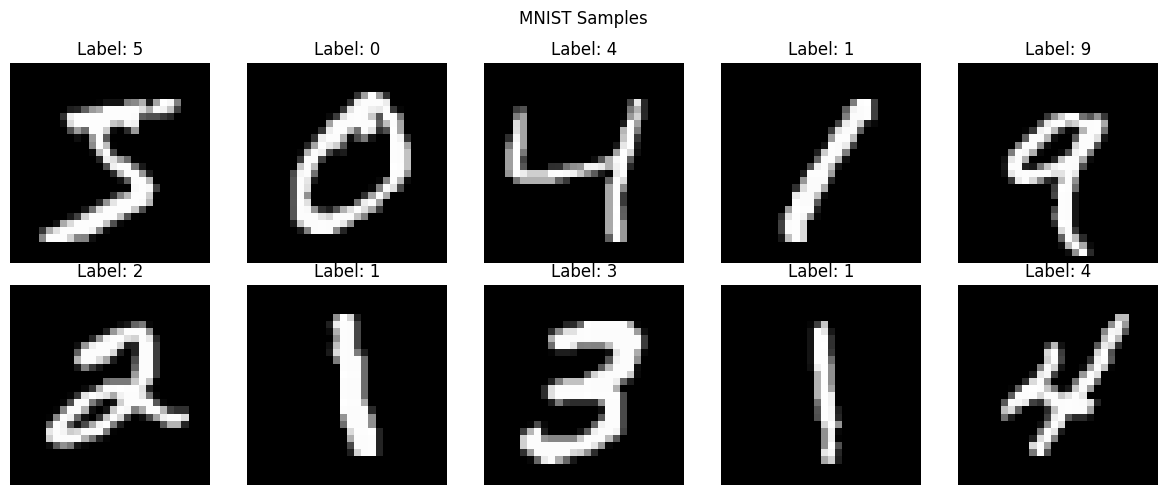

In [3]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

# Visualize samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_dataset[i][0].squeeze(), cmap='gray')
    ax.set_title(f"Label: {train_dataset[i][1]}")
    ax.axis('off')
plt.suptitle("MNIST Samples")
plt.tight_layout()
plt.show()

---
## Part 1: Standard Autoencoder

```
Encoder: 784 -> 256 -> 128 -> 32 (compress)
Decoder: 32 -> 128 -> 256 -> 784 (expand)
Loss:    MSE between input and reconstructed output
```

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        # Encoder: compress 784 -> latent_dim
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        # Decoder: expand latent_dim -> 784
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()    # output between 0-1 (pixel values)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed.view(-1, 1, 28, 28)

ae_model = Autoencoder(latent_dim=32).to(device)
print(ae_model)
print(f"\nTotal parameters: {sum(p.numel() for p in ae_model.parameters()):,}")

Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

Total parameters: 476,720


In [5]:
# Train Autoencoder
ae_optimizer = optim.Adam(ae_model.parameters(), lr=0.001)
ae_losses = []

for epoch in range(20):
    ae_model.train()
    running_loss = 0.0

    for images, _ in train_loader:    # ignore labels — unsupervised!
        images = images.to(device)

        # Forward: reconstruct input
        reconstructed = ae_model(images)

        # Loss: how different is output from input?
        loss = F.mse_loss(reconstructed, images)

        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    ae_losses.append(epoch_loss)

    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d} | Loss: {epoch_loss:.6f}")

print(f"\nFinal Loss: {ae_losses[-1]:.6f}")

Epoch  0 | Loss: 0.052221
Epoch  5 | Loss: 0.012753
Epoch 10 | Loss: 0.009060
Epoch 15 | Loss: 0.007482

Final Loss: 0.006760


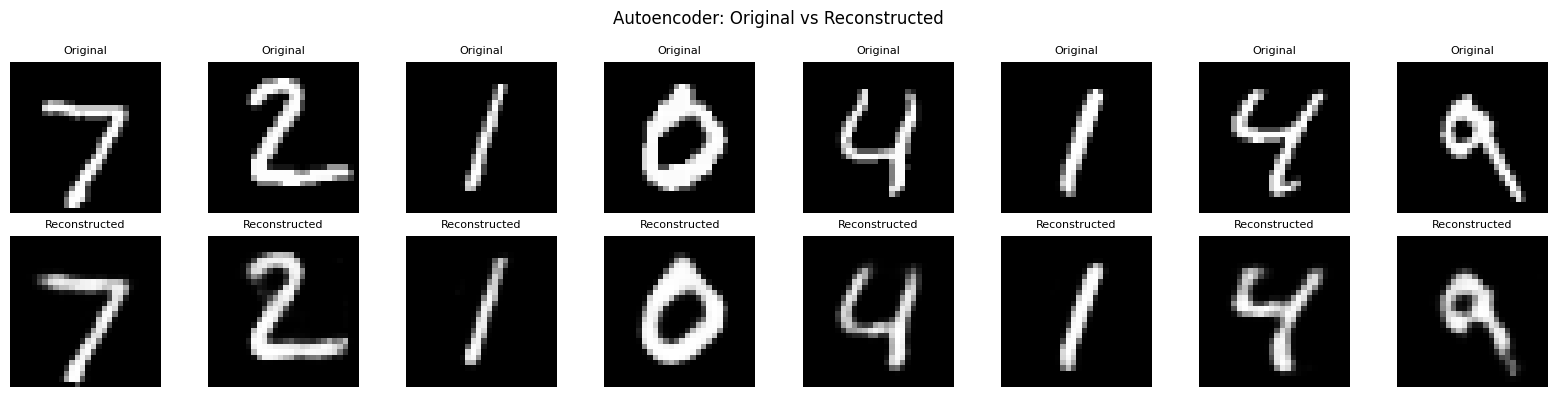

In [7]:
# Visualize reconstructions
ae_model.eval()
test_images, _ = next(iter(test_loader))
test_images = test_images.to(device)

with torch.no_grad():
    reconstructed = ae_model(test_images)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0][i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
    axes[0][i].set_title("Original", fontsize=8)
    axes[0][i].axis('off')

    axes[1][i].imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
    axes[1][i].set_title("Reconstructed", fontsize=8)
    axes[1][i].axis('off')

plt.suptitle("Autoencoder: Original vs Reconstructed")
plt.tight_layout()
plt.show()

---
## Part 2: Variational Autoencoder (VAE)

### Key Differences from Standard Autoencoder
```
Autoencoder encoder -> single point in latent space
VAE encoder         -> mean and std (probability distribution)

VAE adds KL divergence loss to organize the latent space
This allows GENERATING new images by sampling from latent space
```

### Reparameterization Trick
```
Problem: sampling is not differentiable (can't backpropagate)
Solution: z = mean + std * epsilon, where epsilon ~ N(0, 1)
          Now gradients flow through mean and std!
```

In [8]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):    # 2D latent for visualization
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        # VAE outputs mean and log_var (not a single point!)
        self.fc_mu = nn.Linear(128, latent_dim)         # mean
        self.fc_log_var = nn.Linear(128, latent_dim)    # log variance

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        # Reparameterization trick: z = mu + std * epsilon
        std = torch.exp(0.5 * log_var)    # convert log_var to std
        epsilon = torch.randn_like(std)    # random noise ~ N(0,1)
        z = mu + std * epsilon
        return z

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        reconstructed = self.decode(z)
        return reconstructed, mu, log_var

vae_model = VAE(latent_dim=2).to(device)
print(vae_model)
print(f"\nTotal parameters: {sum(p.numel() for p in vae_model.parameters()):,}")

VAE(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
  )
  (fc_mu): Linear(in_features=128, out_features=2, bias=True)
  (fc_log_var): Linear(in_features=128, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

Total parameters: 469,268


In [9]:
def vae_loss(reconstructed, original, mu, log_var):
    """
    VAE Loss = Reconstruction Loss + KL Divergence

    Reconstruction: how well does output match input
    KL Divergence:  how close is latent distribution to N(0,1)
    """
    # Reconstruction loss (binary cross entropy per pixel)
    recon_loss = F.binary_cross_entropy(
        reconstructed.view(-1, 784),
        original.view(-1, 784),
        reduction='sum'
    )

    # KL divergence: pushes latent distribution toward N(0,1)
    # Formula: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    return recon_loss + kl_loss, recon_loss, kl_loss

print("VAE loss function defined!")
print("  Reconstruction loss: output should match input")
print("  KL divergence: latent space should be organized (close to N(0,1))")

VAE loss function defined!
  Reconstruction loss: output should match input
  KL divergence: latent space should be organized (close to N(0,1))


In [10]:
# Train VAE
vae_optimizer = optim.Adam(vae_model.parameters(), lr=0.001)
vae_losses = []
recon_losses = []
kl_losses = []

for epoch in range(30):
    vae_model.train()
    total_loss = 0
    total_recon = 0
    total_kl = 0

    for images, _ in train_loader:
        images = images.to(device)

        reconstructed, mu, log_var = vae_model(images)
        loss, recon, kl = vae_loss(reconstructed, images, mu, log_var)

        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

    n = len(train_loader.dataset)
    vae_losses.append(total_loss / n)
    recon_losses.append(total_recon / n)
    kl_losses.append(total_kl / n)

    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d} | Total: {total_loss/n:.4f} | Recon: {total_recon/n:.4f} | KL: {total_kl/n:.4f}")

print(f"\nFinal Loss: {vae_losses[-1]:.4f}")

Epoch  0 | Total: 191.4808 | Recon: 187.9918 | KL: 3.4890
Epoch  5 | Total: 151.7842 | Recon: 145.9868 | KL: 5.7974
Epoch 10 | Total: 146.0860 | Recon: 139.8558 | KL: 6.2302
Epoch 15 | Total: 143.3457 | Recon: 136.9134 | KL: 6.4324
Epoch 20 | Total: 141.7473 | Recon: 135.2042 | KL: 6.5431
Epoch 25 | Total: 140.4911 | Recon: 133.8474 | KL: 6.6437

Final Loss: 139.9325


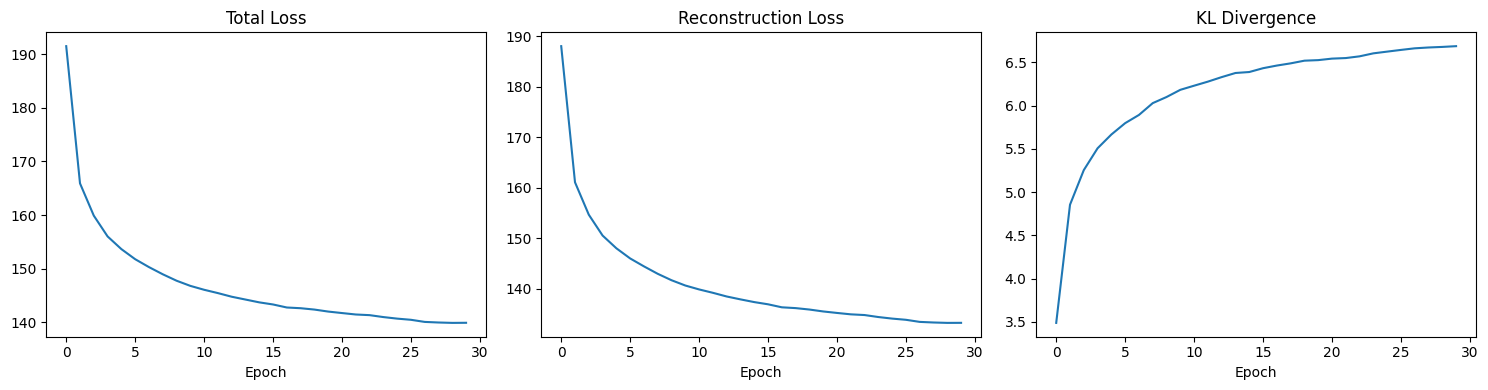

In [11]:
# Plot losses
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(vae_losses)
axes[0].set_title("Total Loss")
axes[0].set_xlabel("Epoch")

axes[1].plot(recon_losses)
axes[1].set_title("Reconstruction Loss")
axes[1].set_xlabel("Epoch")

axes[2].plot(kl_losses)
axes[2].set_title("KL Divergence")
axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

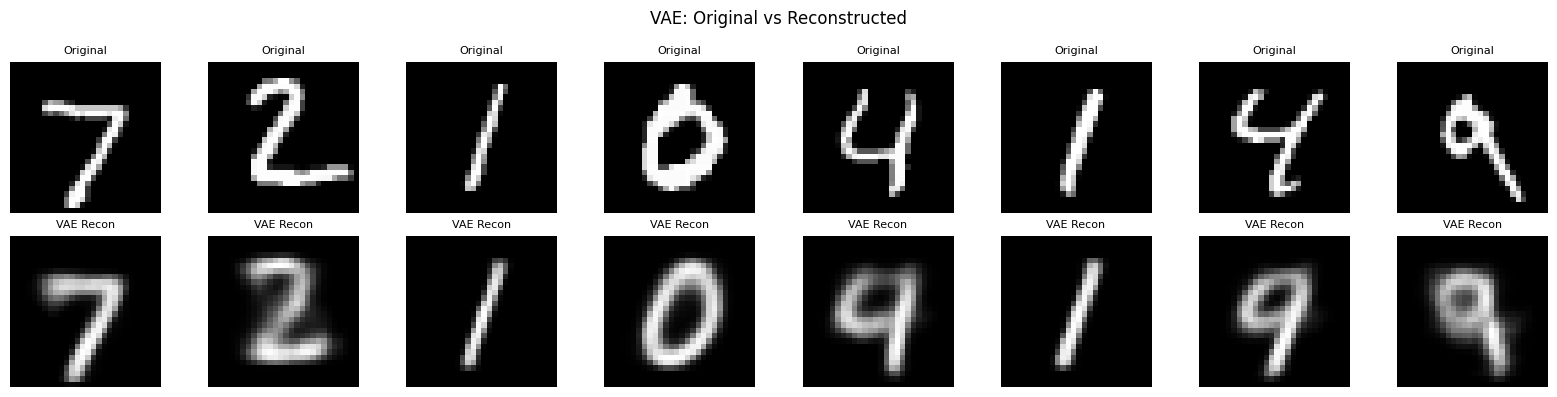

In [12]:
# Visualize VAE reconstructions
vae_model.eval()
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)

with torch.no_grad():
    reconstructed, _, _ = vae_model(test_images)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0][i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
    axes[0][i].set_title("Original", fontsize=8)
    axes[0][i].axis('off')

    axes[1][i].imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
    axes[1][i].set_title("VAE Recon", fontsize=8)
    axes[1][i].axis('off')

plt.suptitle("VAE: Original vs Reconstructed")
plt.tight_layout()
plt.show()

---
## Visualize Latent Space (2D)

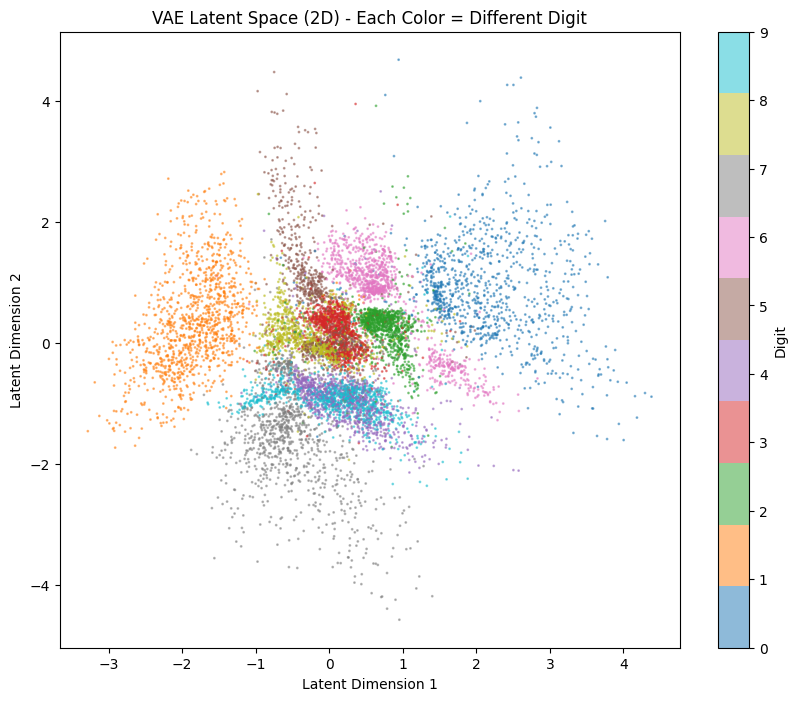

Similar digits cluster together!
Smooth transitions between clusters = VAE can interpolate


In [13]:
# Encode all test images into 2D latent space
vae_model.eval()
all_mu = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        mu, _ = vae_model.encode(images)
        all_mu.append(mu.cpu())
        all_labels.append(labels)

all_mu = torch.cat(all_mu).numpy()
all_labels = torch.cat(all_labels).numpy()

# Plot: each digit gets a different color
plt.figure(figsize=(10, 8))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, cmap='tab10', s=1, alpha=0.5)
plt.colorbar(scatter, label='Digit')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('VAE Latent Space (2D) - Each Color = Different Digit')
plt.show()

print("Similar digits cluster together!")
print("Smooth transitions between clusters = VAE can interpolate")

---
## Generate New Images by Sampling Latent Space

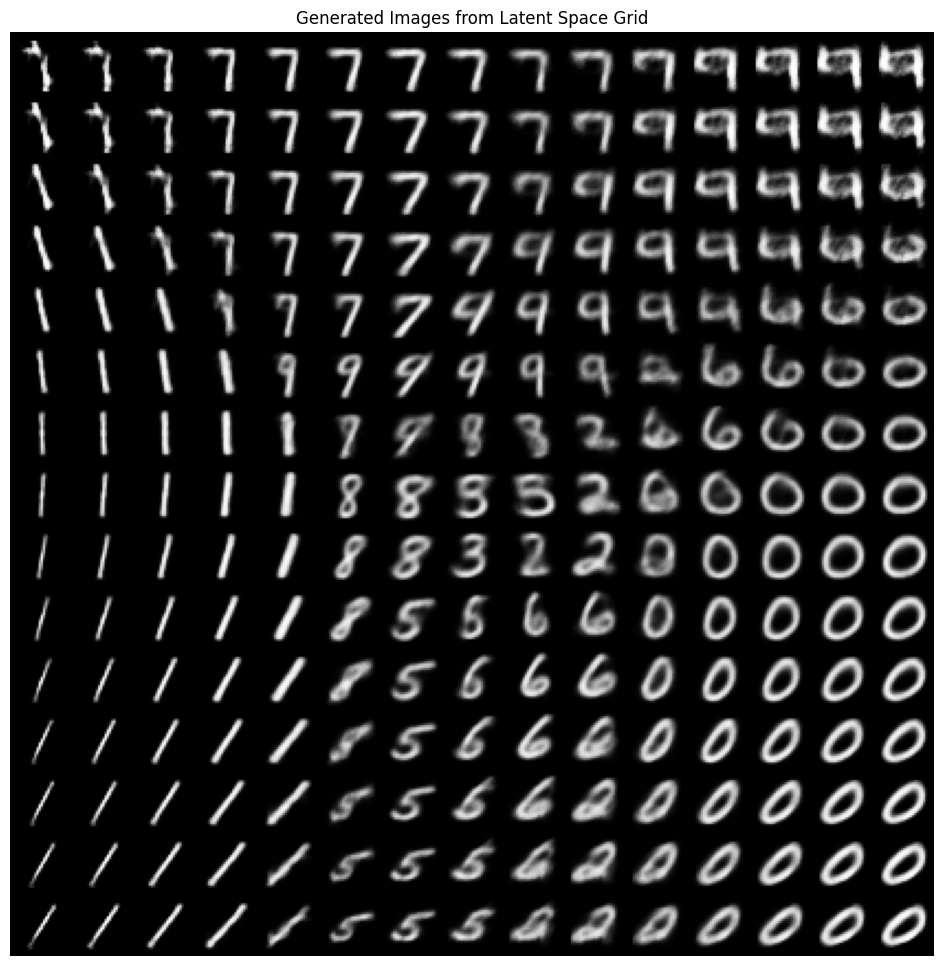

Each position in the grid generates a different digit!
Smooth transitions between digits = organized latent space


In [14]:
# Generate images by sampling from a grid in latent space
vae_model.eval()

n = 15    # 15x15 grid
figure = np.zeros((28 * n, 28 * n))

# Create grid of latent values
grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)

with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            generated = vae_model.decode(z)
            figure[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = generated.cpu().squeeze().numpy()

plt.figure(figsize=(12, 12))
plt.imshow(figure, cmap='gray')
plt.title('Generated Images from Latent Space Grid')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.axis('off')
plt.show()

print("Each position in the grid generates a different digit!")
print("Smooth transitions between digits = organized latent space")

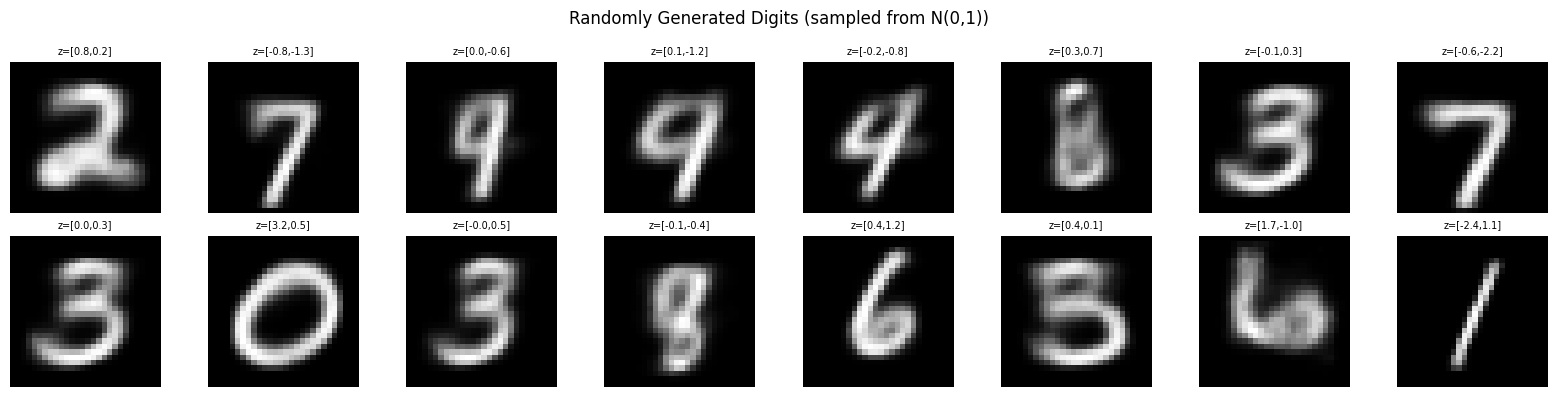

In [15]:
# Generate random new images
vae_model.eval()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

with torch.no_grad():
    for i, ax in enumerate(axes.flat):
        # Sample random point from N(0,1)
        z = torch.randn(1, 2).to(device)
        generated = vae_model.decode(z)
        ax.imshow(generated.cpu().squeeze(), cmap='gray')
        ax.set_title(f"z=[{z[0][0]:.1f},{z[0][1]:.1f}]", fontsize=7)
        ax.axis('off')

plt.suptitle("Randomly Generated Digits (sampled from N(0,1))")
plt.tight_layout()
plt.show()

---
## Interpolation Between Digits

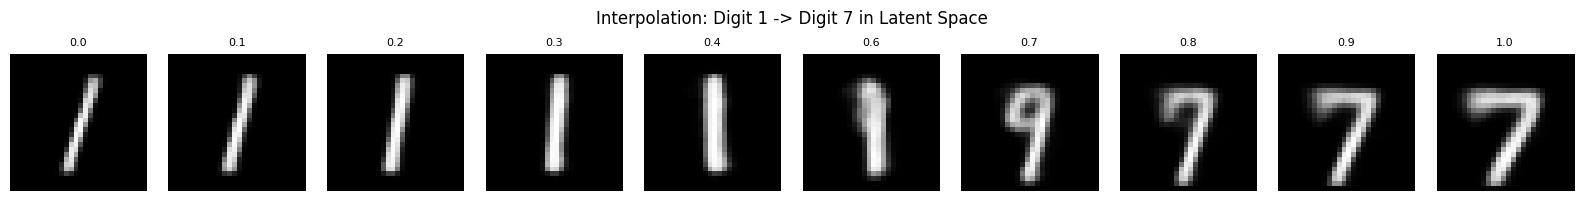

Smooth transition shows the latent space is well-organized!


In [16]:
# Interpolate between two digits in latent space
vae_model.eval()

# Find two different digits
digit_a = None
digit_b = None
for images, labels in test_loader:
    for i in range(len(labels)):
        if labels[i] == 1 and digit_a is None:
            digit_a = images[i:i+1].to(device)
        if labels[i] == 7 and digit_b is None:
            digit_b = images[i:i+1].to(device)
    if digit_a is not None and digit_b is not None:
        break

# Encode both
with torch.no_grad():
    mu_a, _ = vae_model.encode(digit_a)
    mu_b, _ = vae_model.encode(digit_b)

# Interpolate
n_steps = 10
fig, axes = plt.subplots(1, n_steps, figsize=(16, 2))

with torch.no_grad():
    for i, ax in enumerate(axes):
        alpha = i / (n_steps - 1)
        z = (1 - alpha) * mu_a + alpha * mu_b    # linear interpolation
        generated = vae_model.decode(z)
        ax.imshow(generated.cpu().squeeze(), cmap='gray')
        ax.set_title(f"{alpha:.1f}", fontsize=8)
        ax.axis('off')

plt.suptitle("Interpolation: Digit 1 -> Digit 7 in Latent Space")
plt.tight_layout()
plt.show()

print("Smooth transition shows the latent space is well-organized!")

In [17]:
# Save models
torch.save(ae_model.state_dict(), "autoencoder.pth")
torch.save(vae_model.state_dict(), "vae.pth")
print("Models saved!")

Models saved!


---
## Key Takeaways

### Autoencoder vs VAE
```
Autoencoder: encoder -> fixed point -> decoder
  + Good reconstruction
  - Can't generate new images (gaps in latent space)

VAE: encoder -> distribution (mu, sigma) -> sample -> decoder
  + Can generate new images by sampling
  + Organized, smooth latent space
  - Slightly blurrier reconstructions
```

### Concepts Learned
1. **Encoder-Decoder** architecture for unsupervised learning
2. **Latent space** compressed meaningful representation
3. **Reconstruction loss** output should match input
4. **KL divergence** keeps latent space organized as N(0,1)
5. **Reparameterization trick** z = mu + std * epsilon (enables backprop)
6. **Generation** sample from latent space to create new images
7. **Interpolation** smooth transitions between latent points
8. **Unsupervised** no labels needed for training

### VAE Loss
```
Total Loss = Reconstruction Loss + KL Divergence
           = BCE(output, input) + (-0.5 * sum(1 + log_var - mu^2 - exp(log_var)))
```

### Applications
- Image generation (faces, art, designs)
- Data augmentation (generate more training data)
- Anomaly detection (high reconstruction error = anomaly)
- Dimensionality reduction (like PCA but non-linear)
- Drug discovery (generate new molecular structures)

### Test Your Knowledge
- Autoencoder vs VAE difference
- Why KL divergence is needed (organize latent space for generation)
- Reparameterization trick (make sampling differentiable)
- VAE loss = reconstruction + KL
- Why latent space visualization shows clusters
- Discriminative vs generative models